# **Anexo 4: Demanda mensual del SUV medio (MSUV)**

Ejemplo base del enunciado: separar la serie del mercado en sus piezas y ajustar un SARIMAX con variables económicas y calendario. Es un punto de partida, no la solución del caso.

## **Configuración**

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.tsa.seasonal import STL

# Funciona tanto desde la raíz del repositorio como desde examples/
DATA_DIR = Path("data") if Path("data").exists() else Path("../data")
SEGMENT = "MSUV"
VARIABLES = ["paro", "confianza_consumidor", "dias_laborables", "semana_santa"]
LAST_TRAIN_YEAR = 2011  # A011 (año ficticio 2011); A012 se reserva para validar

## **Carga de datos**
Solo las celdas vacías son datos que faltan: si no, el código de modelo `NA` se lee como nulo.

In [2]:
def read_csv(name):
    return pd.read_csv(DATA_DIR / name, keep_default_na=False, na_values=[""])


market = read_csv("mercado_mensual.csv")
macro = read_csv("macro_mensual.csv")

## **Conversión de los años a fechas**
A001 pasa a ser el año ficticio 2001, A002 el 2002, etc. Se conserva el orden y la distancia entre meses.

In [3]:
def to_date(df):
    year = 2000 + df["anio"].str[1:].astype(int)
    return pd.to_datetime(dict(year=year, month=df["mes"], day=1))


market["fecha"] = to_date(market)
macro["fecha"] = to_date(macro)

## **Serie y variables del SUV medio**

- **Serie (`y`)**: coches matriculados cada mes en el mercado del SUV medio, sumando los canales. Es lo que se quiere prever.
- **Variables (`X`)**: paro, confianza del consumidor, días laborables y Semana Santa, tomadas de `macro_mensual.csv`.
- Los días laborables y la Semana Santa se toman del fichero y **no se calculan a partir de la fecha ficticia**, porque los años del caso no coinciden con el calendario real.

<Axes: title={'center': 'Mercado mensual · MSUV'}, xlabel='fecha', ylabel='coches'>

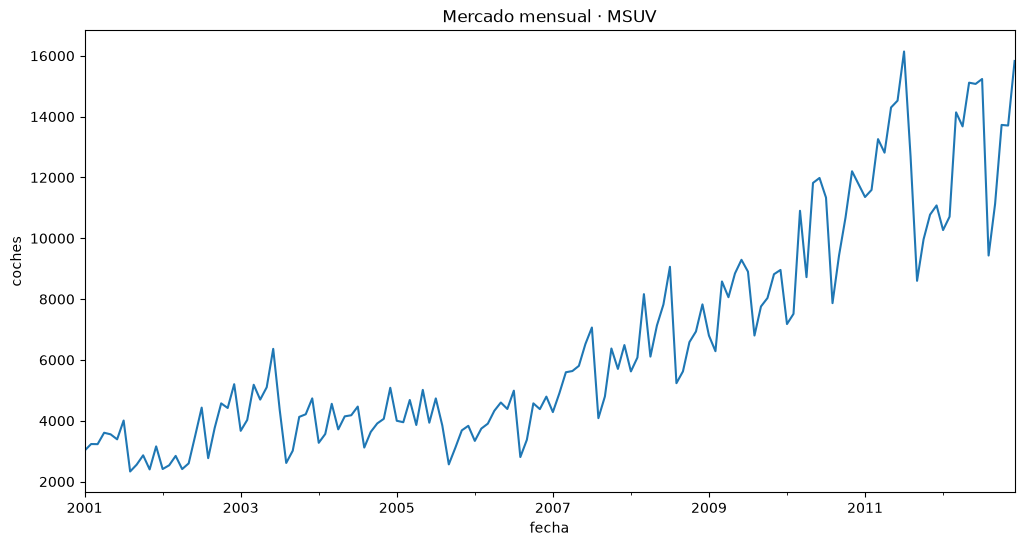

In [5]:
plt.rcParams["figure.figsize"] = (12, 6)

y = (
    market[market["segmento"] == SEGMENT]
    .groupby("fecha")["unidades"].sum()
    .asfreq("MS")
)
X = macro.set_index("fecha")[VARIABLES].asfreq("MS")

y.plot(title=f"Mercado mensual · {SEGMENT}", ylabel="coches")

## **Descomposición STL**

STL separa la serie en tres piezas. Se aplica al logaritmo porque las piezas se multiplican y en logaritmo pasan a sumarse.

- **Tendencia**: el nivel de fondo, lo que se vende en un mes normal. Sube y baja con la economía.
- **Estacionalidad**: cada mes del año se parece al mismo mes de otros años. En este mercado, marzo vende un 25 % más que un mes medio y agosto un 29 % menos.
- **Resto**: lo que queda tras quitar las dos anteriores: efecto del calendario, sucesos (planes de ayuda, cambios de normativa que adelantan compras) y ruido. Una buena previsión deja solo ruido.

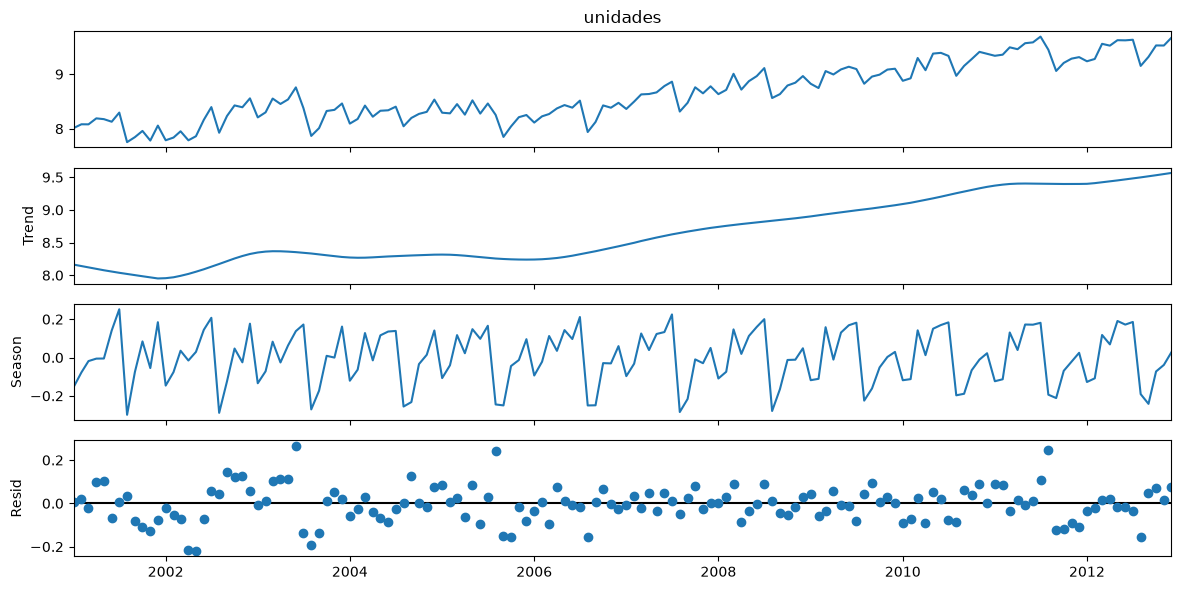

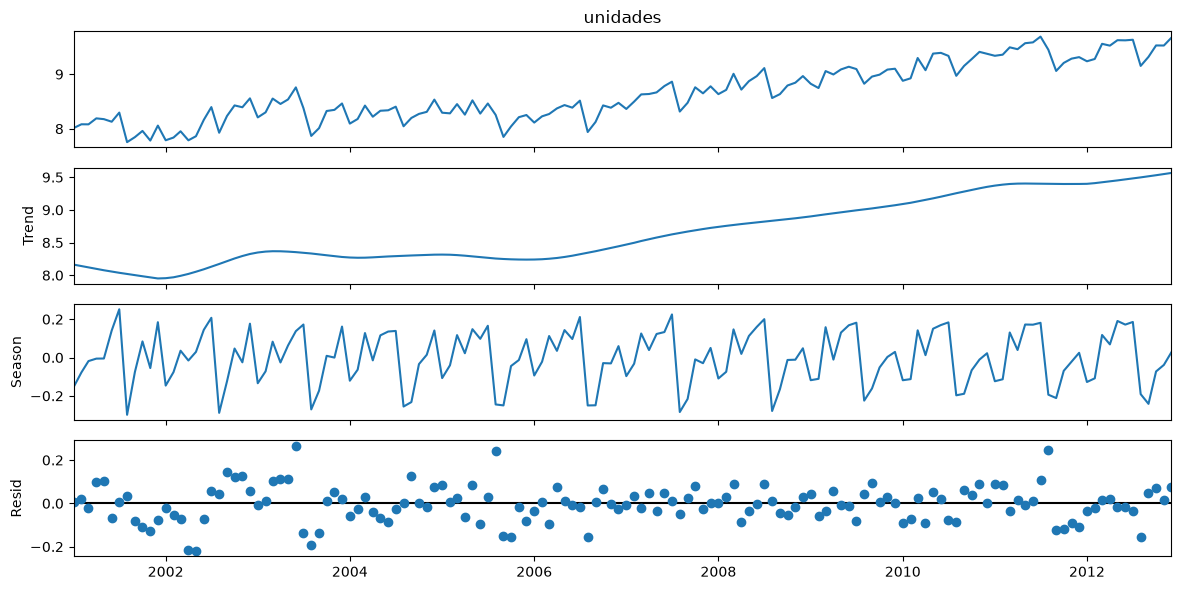

In [ ]:
parts = STL(np.log(y), period=12).fit()
parts.plot()

## **Modelo SARIMAX**

Modelo de series temporales que combina:

- **Parte autorregresiva** (`order=(1, 0, 0)`): el mes actual depende del anterior.
- **Parte estacional** (`seasonal_order=(0, 1, 1, 12)`): se comparan los meses con el mismo mes del año anterior (periodo 12).
- **Variables externas** (`exog`): la economía y el calendario.

Trabaja sobre el logaritmo de las ventas y se deshace con `np.exp` al final.

### **Entrenamiento hasta A011**

Se entrena con los datos hasta A011 (año ficticio 2011) y se reserva A012 para comprobar la previsión, como si A012 fuera el futuro. Después, `model.forecast` prevé los 12 meses de A012.

> Para la previsión se usan los **valores reales de A012** de las variables. Para A013 no se conocen: hay que suponerlos (escenarios) o usar datos de hace unos meses.

In [7]:
is_train = y.index.year <= LAST_TRAIN_YEAR

model = sm.tsa.SARIMAX(
    np.log(y[is_train]),
    exog=X[is_train],
    order=(1, 0, 0),
    seasonal_order=(0, 1, 1, 12),
).fit(
    disp=False,
    maxiter=1000,  # En caso de que salga "ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals"
    # Ocurre cuando hay pocos datos de entrenamiento y el modelo no converge. En ese caso, aumentar el número de iteraciones puede ayudar a que el modelo encuentre una solución.
)

### **Previsión de A012**

Con el modelo entrenado, se prevén los 12 meses de A012 usando las variables de ese año. Se aplica `np.exp` para volver de logaritmo a coches.

In [8]:
forecast = np.exp(model.forecast(12, exog=X[~is_train]))

## **Comparación con A012**

Se compara lo que prevé el modelo con lo que pasó en A012. La tabla muestra las cifras mes a mes y el gráfico, las dos series juntas. Si el modelo convence, se vuelve a estimar con todos los datos para prever A013.

In [9]:
comparison = pd.DataFrame({"real": y[~is_train], "prevision": forecast.round(0)})
comparison

,real,prevision
2012-01-01,10270,10226.0
2012-02-01,10710,9758.0
2012-03-01,14140,11614.0
2012-04-01,13678,10599.0
2012-05-01,15116,12123.0
2012-06-01,15075,11249.0
2012-07-01,15237,13287.0
2012-08-01,9433,8350.0
2012-09-01,11133,8733.0
2012-10-01,13727,11529.0


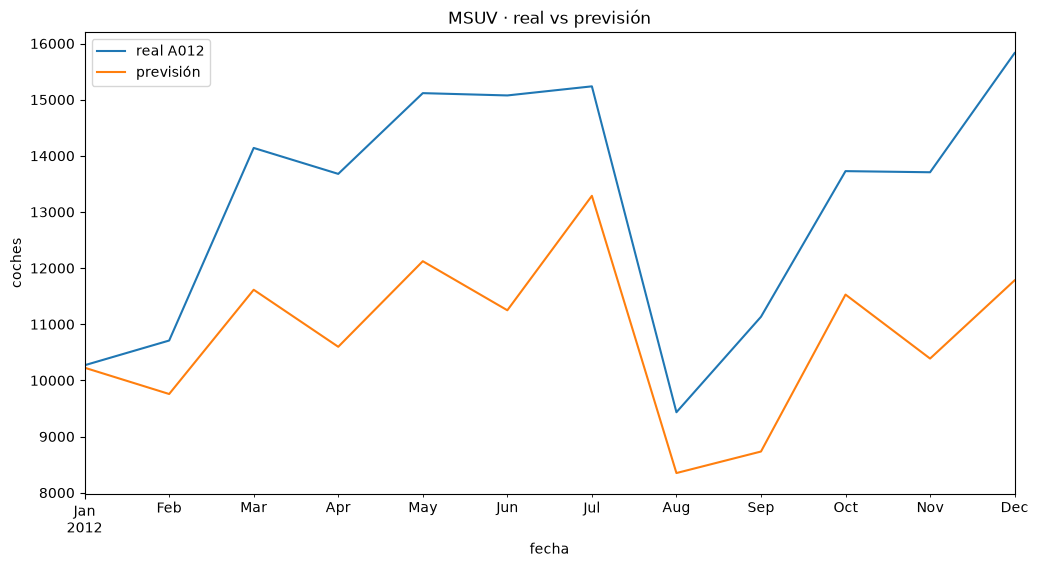

In [10]:
fig, ax = plt.subplots()
y[~is_train].plot(ax=ax, label="real A012")
forecast.plot(ax=ax, label="previsión")
ax.set(title=f"{SEGMENT} · real vs previsión", ylabel="coches")
ax.legend()